### Importação de bibliotecas

In [ ]:
pip show monai || pip install "monai[all]"


In [ ]:
pip show tensorboard || pip install tensorboard

In [ ]:
import glob
import os

import monai
from monai.transforms import LoadImage
from monai.data import DataLoader, Dataset
from monai.data.image_reader import NibabelReader
from monai.data import MetaTensor #Corte
from monai.data import pad_list_data_collate
from monai.utils import first
from monai.transforms import (
    Activations,
    EnsureChannelFirst,
    Compose,
    RandFlip,
    RandRotate,
    RandZoom,
    RandAffine,
    ToTensor,
    ToNumpy,
    SpatialPad
)

import torch
from torch import Tensor
import torch.nn.functional as F
from typing import Tuple
from torchmetrics.classification import BinaryAccuracy

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from torchmetrics.classification import BinaryAccuracy
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt

import numpy as np

import warnings
warnings.filterwarnings('ignore')

from dataclasses import dataclass

# Caso estiver no Google Colab
#from google.colab import drive
#drive.mount('/content/drive')

### Parâmetros

In [74]:
@dataclass(frozen=True)
class DatasetConfig:
    INTERPOLATE_MODE: str = 'nearest'
    INTERPOLATE_SIZE: int = (128,256,256)
    PARA_DATA: bool = True
    BAHIA_DATA: bool = True
    CEARA_DATA: bool = True
    BINARY_DATA: bool =False

@dataclass(frozen=True)
class TrainingConfig:    
    BATCH_SIZE_TRAINING: int = 12
    BATCH_SIZE_VAL: int = 7
    BATCH_SIZE_TEST: int = 8
    NUM_WORKERS: int = 2
    NUM_EPOCHS: int = 1000
    LEARNING_RATE: float = 0.0001
    DATA_AUGMENTATION: bool = True

### Diretórios

In [75]:
# Definir os caminhos das pastas dentro do Google Drive
# Pará
base_dir_homens_para = 'Imagens_Engine/Pará/Máscaras/Homens' 
base_dir_mulheres_para = 'Imagens_Engine/Pará/Máscaras/Mulheres'

# Ceará
base_dir_homens_ceara = 'Imagens_Engine/Ceará/Máscaras/Homens' 
base_dir_mulheres_ceara = 'Imagens_Engine/Ceará/Máscaras/Mulheres'

# Bahia
base_dir_homens_bahia = 'Imagens_Engine/Bahia/Máscaras/Homens' 
base_dir_mulheres_bahia = 'Imagens_Engine/Bahia/Máscaras/Mulheres'

# Buscar arquivos de homens e mulheres para cada estado
# Pará
arquivos_homens_para = glob.glob(os.path.join(base_dir_homens_para, '**', '*.*'), recursive=True)[:-1]
arquivos_mulheres_para = glob.glob(os.path.join(base_dir_mulheres_para, '**', '*.*'), recursive=True)

# Ceará
arquivos_homens_ceara = glob.glob(os.path.join(base_dir_homens_ceara, '**', '*.*'), recursive=True)
arquivos_mulheres_ceara = glob.glob(os.path.join(base_dir_mulheres_ceara, '**', '*.*'), recursive=True)[:8]

# Bahia
arquivos_homens_bahia = glob.glob(os.path.join(base_dir_homens_bahia, '**', '*.*'), recursive=True)
arquivos_mulheres_bahia = glob.glob(os.path.join(base_dir_mulheres_bahia, '**', '*.*'), recursive=True)[:12]

# Todos os estados
arquivos_homens = []
arquivos_mulheres = []

if DatasetConfig.PARA_DATA:
    arquivos_homens += arquivos_homens_para
    arquivos_mulheres += arquivos_mulheres_para
if DatasetConfig.CEARA_DATA:
    arquivos_homens += arquivos_homens_ceara
    arquivos_mulheres += arquivos_mulheres_ceara
if DatasetConfig.BAHIA_DATA:
    arquivos_homens += arquivos_homens_bahia
    arquivos_mulheres += arquivos_mulheres_bahia

# 4. Exibir a quantidade de arquivos encontrados para cada estado
print("=== Arquivos no estado do Pará ===")
print(f"Seios paranasais masculinos: {len(arquivos_homens_para)}")
print(f"Seios paranasais femininos: {len(arquivos_mulheres_para)}")

print("\n=== Arquivos no estado do Ceará ===")
print(f"Seios paranasais masculinos: {len(arquivos_homens_ceara)}")
print(f"Seios paranasais femininos: {len(arquivos_mulheres_ceara)}")

print("\n=== Arquivos no estado da Bahia ===")
print(f"Seios paranasais masculinos: {len(arquivos_homens_bahia)}")
print(f"Seios paranasais femininos: {len(arquivos_mulheres_bahia)}")

print("\n=== Total geral de arquivos ===")
print(f"Total de seios paranasais masculinos: {len(arquivos_homens)}")
print(f"Total de seios paranasais femininos: {len(arquivos_mulheres)}")


=== Arquivos no estado do Pará ===
Seios paranasais masculinos: 34
Seios paranasais femininos: 34

=== Arquivos no estado do Ceará ===
Seios paranasais masculinos: 8
Seios paranasais femininos: 8

=== Arquivos no estado da Bahia ===
Seios paranasais masculinos: 12
Seios paranasais femininos: 12

=== Total geral de arquivos ===
Total de seios paranasais masculinos: 54
Total de seios paranasais femininos: 54


### Funções

1. Carregar volume

In [77]:
#   Correto
#   2.0 → Azul escuro       # Em cima
#   3.0 → Ciano             # Atrás
#   4.0 → Amarelo           # Longe de mim
#   5.0 → Vermelho escuro   # Perto de mim

#--------------------------------------------------------------------------------------

#   Primeiro
#   Em cima → 5.0
#   Atrás → 4.0 
#   Longe de mim → 2.0
#   Perto de mim → 3.0  
wrong_color1 = [
    "1-1333663.nii",
    "2-1335860.nii",
    "5-1403689.nii",
    "7-1428546.nii",
    "11-1471830.nii",
    "13-1496874.nii",
    "15-1507438.nii",
    "16-1508238.nii",
    "17-1509330.nii",
    "18-1667248.nii",
    "19-1674535.nii",
    "20-1691088.nii",
    "21-1352496.nii",
    "22-1384117.nii",
    "23-1461794.nii",
    "25-1515477.nii",
    "26-1545421.nii",
    "27-1546288.nii",
    "28-1574248.nii",
    "31-1668313.nii",
    "32-1675835.nii",
    "33-1676414.nii",
    "34-1276334.nii",
    "38-1247673.nii",
    "39-1347053.nii",
    "40-1456571.nii"
]

#   Segundo
#   Em cima → 2.0
#   Atrás → 5.0 
#   Longe de mim → 3.0
#   Perto de mim → 4.0  
wrong_color2 = [
    "103-1404890.nii",
    "106-1463342.nii",
    "303.nii",
    "305.nii",
    "306.nii",
    "321.nii",
    "322.nii",
    "341.nii",
    "342.nii"
]

'''
#   Terceiro
#   Em cima → 2.0
#   Longe de mim → 3.0
#   Perto de mim → 4.0  
#   Atrás → 3.0
# wrong_color3 = "248.nii" -> frontal-azul, esq-vermelho, dir-azul claro e atras-amarelo
'''

'\n#   Terceiro\n#   Em cima → 2.0\n#   Longe de mim → 3.0\n#   Perto de mim → 4.0  \n#   Atrás → 3.0\n# wrong_color3 = "248.nii" -> frontal-azul, esq-vermelho, dir-azul claro e atras-amarelo\n'

In [78]:
def load_volume(path: str):
    # LoadImage -> MONAI
    loader = LoadImage(image_only=True)
    volume = loader(path)

    if DatasetConfig.BINARY_DATA:
        volume[volume>0] = 1
    else:
        filename = os.path.basename(path)
        volume_orig = volume.clone()
        
        if 6.0 in volume.unique():
            volume = torch.where(volume_orig == 5.0, torch.tensor(4.0), volume)
            volume = torch.where(volume_orig == 6.0, torch.tensor(5.0), volume)
            volume_orig = volume.clone()

        if filename in wrong_color1:
            volume = torch.where(volume_orig == 5.0, torch.tensor(2.0), volume)
            volume = torch.where(volume_orig == 4.0, torch.tensor(3.0), volume)
            volume = torch.where(volume_orig == 2.0, torch.tensor(4.0), volume)
            volume = torch.where(volume_orig == 3.0, torch.tensor(5.0), volume)
        elif filename in wrong_color2:
            volume = torch.where(volume_orig == 4.0, torch.tensor(5.0), volume)
            volume = torch.where(volume_orig == 3.0, torch.tensor(4.0), volume)
            volume = torch.where(volume_orig == 5.0, torch.tensor(3.0), volume)

        volume = torch.where(volume_orig == 2.0, torch.tensor(100.0), volume)
        volume = torch.where(volume_orig == 3.0, torch.tensor(-300.0), volume)
        volume = torch.where(volume_orig == 4.0, torch.tensor(-200.0), volume)
        volume = torch.where(volume_orig == 5.0, torch.tensor(-100.0), volume)
        

    '''
    print(f"-------- Carregamento do volume --------") 
    print(f"Tipo de dado do tensor: {volume.dtype}")                                      # torch.float32
    print(f"Tamanho do tensor: {volume.shape}")                                           # torch.Size([512, 512, 245]) -> (H,W,D)                  
    print(f"Dados presentes no tensor: {volume.unique()}")                                # tensor([0., 2., 3., 4., 5.])
    '''

    return volume 

2. Interpolação

In [79]:
def interpolate_volume(volume: Tensor, vol_size=DatasetConfig.INTERPOLATE_SIZE):
    vol_shape = tuple(volume.shape) # (H,W,D)

    if vol_shape == vol_size:
        return volume
    
    max_dim = max(vol_shape)
    volume = SpatialPad(spatial_size=(max_dim,max_dim,max_dim))(volume.unsqueeze(dim=0)).squeeze(dim=0)
    
    # Troca as posições das dimensões para (D,H,W)
    volume = volume.permute(2,0,1)
    # Adiciona duas dimensões no início para que o .shape seja (Batch,Channel,Depth,Height,Width)
    volume = volume.unsqueeze(0).unsqueeze(0)

    # O interpolate recebe o tensor no formato: mini-batch x channels x [optional depth] x [optional height] x width.
    interpolated = F.interpolate(volume, size=vol_size, mode = DatasetConfig.INTERPOLATE_MODE)[0,0]

    # Retorna um tensor com .shape (D,H,W)
    return interpolated  #passar a tupla retorno a tupla (tensor, shape antigo)

3. Corte

In [80]:
def crop_volume(volume: Tensor, valor_minimo= 0.0) -> MetaTensor:
    # Função auxiliar para encontrar o primeiro slice com valor acima do valor_minimo
    def primeiro_slice(volume, eixo):
        for i in range(volume.shape[eixo]):
            if eixo == 0 and torch.any(volume[i, :, :]) != valor_minimo:
                return i
            elif eixo == 1 and torch.any(volume[:, i, :]) != valor_minimo:
                return i
            elif eixo == 2 and torch.any(volume[:, :, i]) != valor_minimo:
                return i
        return None

    # Função auxiliar para encontrar o último slice com valor acima do valor_minimo
    def ultimo_slice(volume, eixo):
        for i in range(volume.shape[eixo] - 1, -1, -1):
            if eixo == 0 and torch.any(volume[i, :, :]) != valor_minimo:
                return i
            elif eixo == 1 and torch.any(volume[:, i, :]) != valor_minimo:
                return i
            elif eixo == 2 and torch.any(volume[:, :, i]) != valor_minimo:
                return i
        return None

    # Encontrando os slices para cada eixo
    x_primeiro_slice = primeiro_slice(volume, 0)
    x_ultimo_slice = ultimo_slice(volume, 0)
    y_primeiro_slice = primeiro_slice(volume, 1)
    y_ultimo_slice = ultimo_slice(volume, 1)
    z_primeiro_slice = primeiro_slice(volume, 2)
    z_ultimo_slice = ultimo_slice(volume, 2)

    if None in [x_primeiro_slice, x_ultimo_slice, y_primeiro_slice, y_ultimo_slice, z_primeiro_slice, z_ultimo_slice]:
        raise ValueError("Não foram encontrados slices com valores acima do valor mínimo especificado.")

    # Cortando o MetaTensor mantendo os metadados
    volume_cortado = volume[
        x_primeiro_slice-8:x_ultimo_slice + 12, # coloquei +8 e -8 pra deixar 8 slices de margem pro corte, pois antes estava recortando o seios paranasal
        y_primeiro_slice-8:y_ultimo_slice + 12,
        z_primeiro_slice-8:z_ultimo_slice + 12
    ]

    return volume_cortado

4. Normalizar volume

In [81]:
def normalizacao(volume):
    return (volume - volume.min()) / (volume.max() - volume.min())

In [82]:
def zscore_normalization(volume):
    mean = volume.mean()
    std = volume.std()
    return (volume - mean) / std

### Mostrar volume

In [43]:
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

1. Mostra o volume 3D

In [ ]:
def plot_volume(volume, threshold=0.01, colored=True, save=False, folder=None, title=None):
    """
    Plota um volume 3D com cor única ou múltiplas cores dependendo do valor de `colored`.
    
    Args:
        volume (torch.Tensor): Tensor 3D no formato (H, W, D).
        threshold (float): Threshold para o marching cubes.
        colored (bool): Se True, usa cores diferentes para cada valor distinto no volume.
        save (bool): S True, salva a imagem na pasta folder.
        folder (str): caminho relativo na pasta onde a imagem deve ser salva.
        title (str): nome do arquivo a ser salvo na pasta folder.
    """

    if volume.dim() == 4:
        volume = volume.squeeze(0)
        
    volume_np = volume.cpu().numpy()
    p = volume_np.transpose(0, 1, 2)

    if colored:
        unique_values = np.unique(volume_np)
        unique_values = unique_values[unique_values != 0]  # Ignora o fundo

        colors = plt.cm.jet(np.linspace(0, 1, len(unique_values)))

        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

        for value, color in zip(unique_values, colors):
            verts, faces, _, _ = measure.marching_cubes(volume_np == value, 0.5)
            
            mesh = Poly3DCollection(verts[faces], alpha=0.7)
            mesh.set_facecolor(color[:3])  # Apenas RGB
            ax.add_collection3d(mesh)
    else:
        verts, faces, _, _ = measure.marching_cubes(p, threshold)
        mesh = Poly3DCollection(verts[faces], alpha=1.0)
        mesh.set_facecolor([0.45, 0.45, 0.75])  # Azul padrão

        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

        ax.add_collection3d(mesh)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax.view_init(elev=20, azim=10)

    if save and title and folder:
        os.makedirs(folder, exist_ok=True)
        path = os.path.splitext(os.path.basename(title))[0]
        file_name = os.path.join(folder, f"{path}.png")
        plt.savefig(file_name, dpi=300)
        plt.close()
    else:
        plt.show()


2. Plota as fatias 2D

In [ ]:
def plot_slices(first_slice, num_rows, num_columns, width, height, data):
    """
    Exibe uma montagem de fatias de uma imagem 3D em um grid.

    Args:
        data (torch.Tensor): Volume 3D no formato (D, H, W), onde D é o número de fatias.
        first_slice (int): Índice da primeira fatia a ser exibida.
        num_rows (int): Número de linhas no grid de fatias.
        num_columns (int): Número de colunas no grid de fatias.
        height (int): Altura de cada fatia.
        width (int): Largura de cada fatia.
    """
    data = data.cpu().numpy()

    # Transpor o volume para que ele seja plotado na orientação correta (eixos Z, Y, X)
    data= data.transpose(0, 1, 2)

    # Selecionar as fatias necessárias
    total_slices = num_rows * num_columns
    slices = data[first_slice:first_slice + total_slices, :, :]  # Seleciona as fatias para o grid

    # Reformatar os dados para se ajustar ao grid de fatias
    slices = np.reshape(slices, (num_rows, num_columns, height, width))

    # Criar a figura com a montagem
    fig_width = 12.0
    fig_height = fig_width * num_rows / num_columns
    f, axarr = plt.subplots(num_rows, num_columns, figsize=(fig_width, fig_height))

    for i in range(num_rows):
        for j in range(num_columns):
            axarr[i, j].imshow(slices[i, j], cmap="gray")
            axarr[i, j].axis("off")

    plt.subplots_adjust(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    plt.show()

#Versão antiga

def plot_slices(first_slice, num_rows, num_columns, width, height, data):
    """first_slice é a fatia na qual você quer iniciar a imprimir e vai imprimir da primeira fati até a first_slice+(num_rows * num_columns) """"
    """Função para exibir uma montagem de fatias de uma imagem 3D"""
    data = data.cpu().numpy() #perda de memória

    # Transpor o volume para que ele seja plotado na orientação correta (eixos Z, Y, X)
    data= data.transpose(0, 1, 2)

    # Selecionar as fatias necessárias
    total_slices = num_rows * num_columns
    slices = data[first_slice:first_slice + total_slices, :, :]  # Seleciona as fatias para o grid

    # Reformatar os dados para se ajustar ao grid de fatias
    slices = np.reshape(slices, (num_rows, num_columns, height, width))

    # Criar a figura com a montagem
    fig_width = 12.0
    fig_height = fig_width * num_rows / num_columns
    f, axarr = plt.subplots(num_rows, num_columns, figsize=(fig_width, fig_height))

    for i in range(num_rows):
        for j in range(num_columns):
            axarr[i, j].imshow(slices[i, j], cmap="gray")
            axarr[i, j].axis("off")

    plt.subplots_adjust(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    plt.show()


'\ndef plot_slices(first_slice, num_rows, num_columns, width, height, data):\n    """first_slice é a fatia na qual você quer iniciar a imprimir e vai imprimir da primeira fati até a first_slice+(num_rows * num_columns) """"\n    """Função para exibir uma montagem de fatias de uma imagem 3D"""\n    data = data.cpu().numpy() #perda de memória\n\n    # Transpor o volume para que ele seja plotado na orientação correta (eixos Z, Y, X)\n    data= data.transpose(0, 1, 2)\n\n    # Selecionar as fatias necessárias\n    total_slices = num_rows * num_columns\n    slices = data[first_slice:first_slice + total_slices, :, :]  # Seleciona as fatias para o grid\n\n    # Reformatar os dados para se ajustar ao grid de fatias\n    slices = np.reshape(slices, (num_rows, num_columns, height, width))\n\n    # Criar a figura com a montagem\n    fig_width = 12.0\n    fig_height = fig_width * num_rows / num_columns\n    f, axarr = plt.subplots(num_rows, num_columns, figsize=(fig_width, fig_height))\n\n    for 

3. Salva a representação do volume: Normal, com Corte e com Corte + Interpolação.

In [ ]:
def show_processed_volumes(volume, folder_path=None, save=False, threshold=0.01):
    file_name = volume
    v1 = load_volume(volume)
    v2 = crop_volume(v1)
    v3 = interpolate_volume(v2).permute(1,2,0)
    
    fig = plt.figure(figsize=(18, 6))  # Tamanho maior para caber os 3 gráficos

    for i, (volume, titulo) in enumerate(zip([v1,v2,v3], ["Normal", "Corte", "Corte + Interpolação"])):
        if volume.dim() == 4:
            volume = volume.squeeze(0)

        volume_np = volume.cpu().numpy()

        unique_values = np.unique(volume_np)
        unique_values = unique_values[unique_values > 0]

        color_map = {
            2.0: "#00008B",  # Azul escuro
            3.0: "#00FFFF",  # Ciano
            4.0: "#FFFF00",  # Amarelo
            5.0: "#8B0000"   # Vermelho escuro
        }

        ax = fig.add_subplot(1, 3, i + 1, projection='3d')

        for value in unique_values:
            if value in color_map:
                color = color_map[value]
                verts, faces, _, _ = measure.marching_cubes(volume_np == value, threshold)
                mesh = Poly3DCollection(verts[faces], alpha=0.7)
                mesh.set_facecolor(color)
                ax.add_collection3d(mesh)


        # Fixar limites para consistência
        ax.set_xlim(0, 256)
        ax.set_ylim(0, 256)
        ax.set_zlim(0, 128)

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(titulo)
        ax.view_init(elev=80, azim=30)

    if save and file_name and folder_path:
        os.makedirs(folder_path, exist_ok=True)
        path = os.path.splitext(os.path.basename(file_name))[0]
        file_name = os.path.join(folder_path, f"{path}.png")
        plt.savefig(file_name, dpi=300)
        plt.close()
    else:
        plt.tight_layout()
        plt.show()

'''
# Salva as imagens
for path in arquivos_homens:
    show_processed_volumes(path,folder_path="Image Plot correto/Homens", save=True)

for path in arquivos_mulheres:
    show_processed_volumes(path,folder_path="Image Plot correto/Mulheres", save=True)
'''


Valores únicos antes do corte: metatensor([-300., -200., -100.,    0.,  100.])
Valores únicos depois do corte: metatensor([-300., -200., -100.,    0.,  100.])
Valores únicos antes do corte: metatensor([-300., -200., -100.,    0.,  100.])
Valores únicos depois do corte: metatensor([-300., -200., -100.,    0.,  100.])


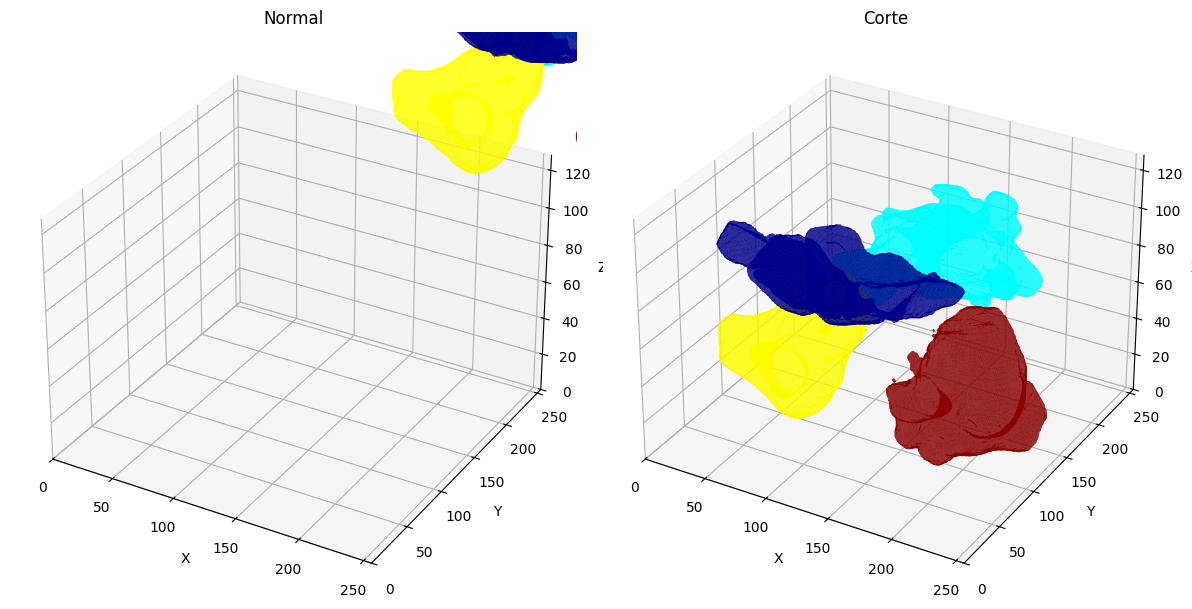

In [83]:
def show_processed_volumes(volume, folder_path=None, save=False, threshold=0.01):
    file_name = volume
    v1 = load_volume(volume)
    v2 = crop_volume(v1)
    
    fig = plt.figure(figsize=(12, 6))  # Ajustado para 2 gráficos

    for i, (vol, titulo) in enumerate(zip([v1, v2], ["Normal", "Corte"])):
        if vol.dim() == 4:
            vol = vol.squeeze(0)

        volume_np = vol.cpu().numpy()
        unique_values = np.unique(volume_np)
        unique_values = unique_values[unique_values > -400]

        print("Valores únicos antes do corte:", torch.unique(v1))
        print("Valores únicos depois do corte:", torch.unique(v2))

        color_map = {
            100.0: "#00008B",  # Azul escuro
            -300.0: "#00FFFF",  # Ciano
            -200.0: "#FFFF00",  # Amarelo
            -100.0: "#8B0000",  # Vermelho escuro
        }

        ax = fig.add_subplot(1, 2, i + 1, projection='3d')

        for value in unique_values:
            if value in color_map:
                color = color_map[value]
                verts, faces, _, _ = measure.marching_cubes(volume_np == value, threshold)
                mesh = Poly3DCollection(verts[faces], alpha=0.7)
                mesh.set_facecolor(color)
                ax.add_collection3d(mesh)

        ax.set_xlim(0, 256)
        ax.set_ylim(0, 256)
        ax.set_zlim(0, 128)

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(titulo)

    if save and file_name and folder_path:
        os.makedirs(folder_path, exist_ok=True)
        path = os.path.splitext(os.path.basename(file_name))[0]
        file_name = os.path.join(folder_path, f"{path}.png")
        plt.savefig(file_name, dpi=300)
        plt.close()
    else:
        plt.tight_layout()
        plt.show()

#for path in arquivos_homens:
#    show_processed_volumes(path,folder_path="Image Plot correto/Homens", save=True)

#for path in arquivos_mulheres:
#    show_processed_volumes(path,folder_path="Image Plot correto/Mulheres", save=True)

show_processed_volumes("Imagens_Engine/Bahia/Máscaras/Homens/18 a 29 anos/124.nii")

In [15]:
show_processed_volumes(arquivos_homens[2])

KeyboardInterrupt: 

6. Teste

In [ ]:
def volume_processing(volume_path: str, crop_thr: float):
    print(f"Carregando: {volume_path}")
    volume = load_volume(volume_path)
    print(f"Forma e tipo do volume: {volume.shape} >> {volume.dtype}")

    print(f"Volume normal:")
    plot_volume(volume)
    #plot_slices(100, 5, 10, 512, 512, volume)

    volume = crop_volume(volume, crop_thr)
    print(f"Volume cortado: {volume.shape} >> {volume.dtype}")

    volume = interpolate_volume(volume)
    print(f"Tamanho após a interpolação: {volume.shape} >> {volume.dtype} >> {volume.unique()}")

    print(f"Volume cortado + interpolado: ")
    plot_volume(volume)
    #plot_slices(5,5, 10, volume.size(2), volume.size(1), volume)

    volume = normalizacao(volume)
    print(f"Valores presentes após a normalização: {volume.shape} >> {volume.dtype} >> {volume.unique()}")
    print(f"Volume cortado + interpolado + normalizado: ")
    plot_volume(volume)
    #plot_slices(5,5, 10, volume.size(2), volume.size(1), volume)

    return volume

#Teste
volume = volume_processing(arquivos_homens[50] ,crop_thr=0.0)

#### Dataframes

In [ ]:
import pandas as pd

load_homens = []
shape_homens = []

# Preencher os dados
for i in range(len(arquivos_homens)):
    load_homens.append(load_volume(arquivos_homens[i]))
    shape_homens.append({
        'Caminho da imagem': os.path.basename(arquivos_homens[i]),
        'Tamanho': load_homens[i].shape,
    })

# Criar o DataFrame a partir da lista
df_homens = pd.DataFrame(shape_homens)

# Exibir o DataFrame
print(df_homens)

   Caminho da imagem          Tamanho
0     48-1241756.nii  (231, 512, 512)
1     53-1334976.nii  (224, 512, 512)
2     43-1511025.nii  (242, 512, 512)
3     47-1649198.nii  (287, 512, 512)
4     50-1501462.nii  (240, 512, 512)
5     49-1244543.nii  (250, 512, 512)
6     54-1634854.nii  (287, 512, 512)
7     52-1321855.nii  (245, 512, 512)
8     39-1347053.nii  (482, 512, 512)
9     32-1675835.nii  (235, 512, 512)
10    26-1545421.nii  (239, 512, 512)
11    25-1515477.nii  (299, 512, 512)
12    40-1456571.nii  (222, 512, 512)
13    21-1352496.nii  (297, 512, 512)
14    33-1676414.nii  (272, 512, 512)
15    23-1461794.nii  (253, 512, 512)
16    28-1574248.nii  (267, 512, 512)
17    31-1668313.nii  (305, 512, 512)
18    34-1276334.nii  (567, 512, 512)
19    22-1384117.nii  (470, 512, 512)
20    27-1546288.nii  (490, 512, 512)
21    38-1247673.nii  (449, 512, 512)
22    13-1496874.nii  (244, 512, 512)
23    20-1691088.nii  (598, 512, 512)
24     1-1333663.nii  (199, 512, 512)
25    15-150

In [ ]:
df_homens.to_csv('df_homens.csv', index=False)

In [ ]:
# Encontrar o menor valor da primeira posição da tupla na coluna 'Tamanho'
menor_altura = min(df_homens['Tamanho'], key=lambda x: x[0])[0]

print(f"Menor altura encontrada: {menor_altura}")

Menor altura encontrada: 161


In [ ]:
import pandas as pd

load_mulheres = []
shape_mulheres = []

# Preencher os dados
for i in range(len(arquivos_mulheres)):
    load_mulheres.append(load_volume(arquivos_mulheres[i]))
    shape_mulheres.append({
        'Caminho da imagem': os.path.basename(arquivos_mulheres[i]),
        'Tamanho': load_mulheres[i].shape,
    })

# Criar o DataFrame a partir da lista
df_mulheres = pd.DataFrame(shape_mulheres)

# Exibir o DataFrame
print(df_mulheres)

In [ ]:
df_mulheres.to_csv('df_mulheres.csv', index=False)

In [ ]:
# Encontrar o menor valor da primeira posição da tupla na coluna 'Tamanho'
menor_altura = min(df_mulheres['Tamanho'], key=lambda x: x[0])[0]

print(f"Menor altura encontrada: {menor_altura}")

Menor altura encontrada: 109


In [ ]:
load_mulheres = [load_volume(arquivo) for arquivo in arquivos_mulheres]

shape_mulheres = []

for i in range(len(arquivos_mulheres)):
    shape_mulheres.append({
        'Caminho da imagem': os.path.basename(arquivos_mulheres[i]),
        'Tamanho': arquivos_mulheres[i].shape,
    }) 

df_mulheres = pd.DataFrame(shape_mulheres)

print(df_mulheres)

KeyboardInterrupt: 

### Preparo dos Datasets do Treinamento, Validação e Teste

In [61]:
num_class = 2

# cria uma lista em que cada posição é uma lista com todos os caminhos de cada label
image_files = [
    sorted(arquivos_homens), sorted(arquivos_mulheres)
]

# quantidade de imagens para cada classe  -> Homens (0) - Mulheres (1)
num_each = [len(image_files[i]) for i in range(num_class)]

X = [] #tera todos os caminhos
y = []
class_names = ["Homens", "Mulheres"]

for i in range(num_class):
    X.extend(image_files[i]) #extend adiciona todos os caminhos daquela classe a outra lista
    y.extend([i] * num_each[i]) # cria uma lista com os labels respectivos

num_total = len(y)

print(f"Total de imagens: {num_total}")
print(f"Nome das classes: {class_names}")
print(f"Número de rótulos: {num_each}")

Total de imagens: 108
Nome das classes: ['Homens', 'Mulheres']
Número de rótulos: [54, 54]


In [62]:
from sklearn.model_selection import train_test_split

#Frações para a divisão do dataset
test_frac = 0.2
val_frac = 0.2

train_x, test_x, train_y, test_y = train_test_split(X,y , random_state=204,  test_size=test_frac,  shuffle=True, stratify=y)

#deu bom 204
#deu ruim 104
train_x, val_x, train_y, val_y = train_test_split(train_x,train_y, random_state=204,  test_size=val_frac,  shuffle=True, stratify=train_y)

In [63]:
print(f"Dados para treinamento:")
print(train_x)
print(f"Labels para treinamento:")
print(train_y)

print("-" * 90)
print(f"Dados para validação:")
print(val_x)
print("-" * 90)
print(f"Labels para validação:")
print(val_y)

print("-" * 90)
print(f"Dados para teste:")
print(test_x)
print("-" * 90)
print(f"Labels para teste:")
print(test_y)

print("-" * 90)
print(f"Treino")
print(f"Quantidade de homens: {train_y.count(0)}, Quantidade de mulheres: {train_y.count(1)}")
print(f"\nValidação")
print(f"Quantidade de homens: {val_y.count(0)}, Quantidade de mulheres: {val_y.count(1)}")
print(f"\nTeste")
print(f"Quantidade de homens: {test_y.count(0)}, Quantidade de mulheres: {test_y.count(1)}")


Dados para treinamento:
['Imagens_Engine/Pará/Máscaras/Homens/30 a 39 anos/22-1384117.nii', 'Imagens_Engine/Ceará/Máscaras/Mulheres/18 a 29 anos/302.nii', 'Imagens_Engine/Pará/Máscaras/Mulheres/30 a 39 anos/87-1371776.nii', 'Imagens_Engine/Pará/Máscaras/Homens/18 a 29 anos/13-1496874.nii', 'Imagens_Engine/Pará/Máscaras/Homens/40 a 49 anos/52-1321855.nii', 'Imagens_Engine/Pará/Máscaras/Mulheres/18 a 29 anos/78-1583821.nii', 'Imagens_Engine/Ceará/Máscaras/Homens/18 a 29 anos/245.nii', 'Imagens_Engine/Pará/Máscaras/Homens/30 a 39 anos/33-1676414.nii', 'Imagens_Engine/Ceará/Máscaras/Mulheres/18 a 29 anos/306.nii', 'Imagens_Engine/Pará/Máscaras/Homens/40 a 49 anos/49-1244543.nii', 'Imagens_Engine/Pará/Máscaras/Homens/40 a 49 anos/47-1649198.nii', 'Imagens_Engine/Pará/Máscaras/Homens/30 a 39 anos/28-1574248.nii', 'Imagens_Engine/Pará/Máscaras/Mulheres/40 a 49 anos/120-1491631.nii', 'Imagens_Engine/Pará/Máscaras/Homens/30 a 39 anos/21-1352496.nii', 'Imagens_Engine/Pará/Máscaras/Mulheres/30 a 

Dataset e DataLoaders

In [64]:
transforms = [
    load_volume,
    crop_volume,  
    interpolate_volume, 
    EnsureChannelFirst()
]

data_aug_transforms = [
    RandRotate(range_x=np.pi / 18, prob=0.5, keep_size=True),
    RandFlip(spatial_axis=0, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAffine(prob=0.5, shear_range=(0.1,0.1,0.1))       
]

train_transforms = transforms.copy()
if TrainingConfig.DATA_AUGMENTATION:
    train_transforms += data_aug_transforms

train_transforms = Compose(train_transforms)
val_transforms = Compose(transforms)

  # image_only=True garante que somente a imagem em si é retornada, coloca o canal primeiro e Normaliza os valores de intensidade da imagem


In [65]:
class ParanasalSinusesDataset(torch.utils.data.Dataset): # é uma classe base do Pytorch -> torch.utils.data.Dataset
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]

# Datasets
train_ds = ParanasalSinusesDataset(train_x, train_y, train_transforms)
train_loader = DataLoader(train_ds, batch_size=TrainingConfig.BATCH_SIZE_TRAINING, shuffle=True, num_workers=TrainingConfig.NUM_WORKERS, collate_fn=pad_list_data_collate)

val_ds = ParanasalSinusesDataset(val_x, val_y, val_transforms)
val_loader = DataLoader(val_ds, batch_size=TrainingConfig.BATCH_SIZE_VAL, num_workers=TrainingConfig.NUM_WORKERS, collate_fn=pad_list_data_collate)

test_ds = ParanasalSinusesDataset(test_x, test_y, val_transforms)
test_loader = DataLoader(test_ds, batch_size=TrainingConfig.BATCH_SIZE_TRAINING, num_workers=TrainingConfig.NUM_WORKERS, collate_fn=pad_list_data_collate)

# O DataLoader agrupa várias imagens em lotes. Ao iterar sobre ele, você recebe os tensores correspondentes às imagens e rótulos no lote. O exemplo acima pega apenas a primeira imagem e rótulo do primeiro lote.

Salvar os tensores

In [66]:
def save_transformed_data(loader, save_path):
    all_images = []
    all_labels = []

    for images, labels in loader:
        all_images.append(images)  # já estão transformadas
        all_labels.append(labels)

    # Concatena os batches
    images_tensor = torch.cat(all_images)
    labels_tensor = torch.cat(all_labels)

    # Salva como .pt (PyTorch)
    torch.save({'images': images_tensor, 'labels': labels_tensor}, save_path)
    print(f'Dados salvos em: {save_path}')

# Salvar os dados transformados antes do treinamento
save_transformed_data(train_loader, 'dados_treinamento_transformados.pt')
save_transformed_data(val_loader, 'dados_validacao_transformados.pt')
save_transformed_data(test_loader, 'dados_teste_transformados.pt')


KeyboardInterrupt: 

Divisão para treinamento, validação e teste

In [ ]:
print(f"Tamanho do dataset de treinamento: {len(train_ds)}")
print(f"Tamanho do dataset de validação: {len(val_ds)}")
print(f"Tamanho do dataset de teste: {len(test_ds)}")

Tamanho do dataset de treinamento: 68
Tamanho do dataset de validação: 18
Tamanho do dataset de teste: 22


Teste

Shape do tensor da imagem: torch.Size([1, 128, 256, 256])
Tensor da imagem:
 metatensor([-200.0000, -199.9901, -199.9850,  ...,   99.9990,   99.9996,
         100.0000])
Precision do tensor:
 torch.float32
Rótulo correspondente: 0
Tensor da imagem:
 metatensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  .

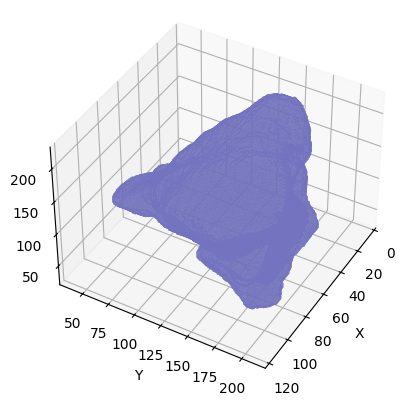

In [ ]:
# Acessando a primeira imagem (tensor) e o rótulo no dataset de treinamento
image_tensor, label= train_ds[0]

# Exibindo a forma do tensor da imagem e o rótulo
print("Shape do tensor da imagem:", image_tensor.shape)
print("Tensor da imagem:\n", image_tensor.unique())
print("Precision do tensor:\n", image_tensor.dtype)
print("Rótulo correspondente:", label)
print("Tensor da imagem:\n", image_tensor)
print("Visualização da imagem:")
plot_volume(image_tensor,colored=False)


### Redes Neurais

In [32]:
# Bibliotecas utilizadas
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import *

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Função para verificar os parâmetrôs treináveis
def parametros_treinaveis(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total de parâmetros: {total_params}")
    print(f"Parâmetros treináveis: {trainable_params}")

### Resnets do MONAI com pesos do MED3D

Resnet10

In [ ]:
from monai.networks.nets import resnet10

model = resnet10(
    pretrained=True,
    spatial_dims=3,
    n_input_channels=1,
    num_classes=2,
    feed_forward=False,
    shortcut_type='B',        
    bias_downsample=False  
)

print(model)

Resnet18

In [41]:
from monai.networks.nets import resnet18

model = resnet18(
    pretrained=True,
    spatial_dims=3,
    n_input_channels=1,
    num_classes=2,
    feed_forward=False,
    shortcut_type='A',        
    bias_downsample=True
)

print(model)

ResNet(
  (conv1): Conv3d(1, 64, kernel_size=(7, 7, 7), stride=(1, 1, 1), padding=(3, 3, 3), bias=False)
  (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): ReLU(inplace=True)
  (maxpool): MaxPool3d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResNetBlock(
      (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
      (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResNetBlock(
      (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

Resnet34

In [ ]:
from monai.networks.nets import resnet34

model = resnet34(
    pretrained=True,
    spatial_dims=3,
    n_input_channels=1,
    num_classes=1,
    feed_forward=False,
    shortcut_type='A',        
    bias_downsample=True
)

print(model)

Resnet50

In [19]:
from monai.networks.nets import resnet50

model = resnet50(
    pretrained=True,
    spatial_dims=3,
    n_input_channels=1,
    num_classes=1,
    feed_forward=False,
    shortcut_type='B',        
    bias_downsample=False
)

print(model)

ResNet(
  (conv1): Conv3d(1, 64, kernel_size=(7, 7, 7), stride=(1, 1, 1), padding=(3, 3, 3), bias=False)
  (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): ReLU(inplace=True)
  (maxpool): MaxPool3d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResNetBottleneck(
      (conv1): Conv3d(64, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv3d(64, 256, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
      (bn3): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv3d(64, 25

Transfer Learning

In [20]:
# Congela todos os pesos 
for param in model.parameters():  
    param.requires_grad = False

# Coloca apenas um neurônio de saída
model.fc= nn.Sequential(
    nn.Flatten(),
    nn.Linear(512,1),
    nn.Sigmoid()
)

parametros_treinaveis(model)

Total de parâmetros: 46155585
Parâmetros treináveis: 513


### Testes de redes do Monai Zoo


In [ ]:
# colocar isso no terminal
# python -m monai.bundle download --name spleen_ct_segmentation --bundle_dir "./"

SyntaxError: invalid syntax (8680303.py, line 1)

In [12]:
from monai.networks.nets import SwinUNETR

model = SwinUNETR(
    img_size=(128, 128, 128),  # Ajuste conforme necessário
    in_channels=1,
    out_channels=1,  # Ajuste conforme necessário
    feature_size=48,
    drop_rate=0.0,
    attn_drop_rate=0.0,
    dropout_path_rate=0.0,
    use_checkpoint=False
)

!wget -O ../data/model_swinvit.pt https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/model_swinvit.pt
weight = torch.load("../data/model_swinvit.pt")
model.load_from(weights=weight)


../data/model_swinvit.pt: No such file or directory


FileNotFoundError: [Errno 2] No such file or directory: '../data/model_swinvit.pt'

In [ ]:
#from monai.zoo import download
from monai.config import ConfigParser
from torch.utils.data import DataLoader

# --- 1. Baixar modelo MONAI Zoo ---
model_name = "spleen_ct_segmentation"
zoo_dir = os.path.abspath("./models")

# --- 2. Configuração do modelo ---
model_config_file = os.path.join(zoo_dir, model_name, "configs", "inference.json")
model_config = ConfigParser()
model_config.read_config(model_config_file)

# Definir dispositivo
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Atualizar configurações
model_config["bundle_root"] = zoo_dir

# --- 3. Carregar o modelo ---
model = model_config.get_parsed_content("network").to(device)

# Carregar pesos do modelo
checkpoint = os.path.join(zoo_dir, model_name, "models", "model.pt")
model.load_state_dict(torch.load(checkpoint, map_location=device))

# --- 4. Substituir o DataLoader por um PyTorch DataLoader ---
# Suponha que você já tenha um dataset PyTorch:
# Exemplo: Seu dataset personalizado
from monai.data import Dataset
from monai.transforms import Compose, LoadImage, EnsureChannelFirst, ScaleIntensity

# Transformações
transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ScaleIntensity(),
]

# --- 5. Rodar Inferência ---
model.eval()
with torch.no_grad():
    for batch in dataloader:
        inputs = batch.to(device)
        outputs = model(inputs)
        print(outputs.shape)  # Ver a saída do modelo


ImportError: cannot import name 'ConfigParser' from 'monai.config' (/home/labian-2/Desktop/Crateus/odonto_forense/.venv/lib/python3.12/site-packages/monai/config/__init__.py)

In [3]:
from monai.bundle import load
import torch
import torch.nn as nn

# Carregar o modelo
bundle_dir = "./spleen_ct_segmentationn"  # Caminho para o modelo baixado
model = load(bundle_dir)

# Agora, vamos modificar o modelo, removendo o decoder e colocando uma camada FC
# Exemplo de como acessar o encoder e substituir o decoder:
encoder = model['encoder']  # Pegando o encoder
encoder_fc = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=encoder_output_size, out_features=512),  # Ajuste para o número de características do encoder
    nn.ReLU(),
    nn.Linear(512, 2)  # Saída para 2 classes
)

# Substituindo o decoder
model['decoder'] = encoder_fc

# Agora, o modelo está pronto para ser treinado no seu próprio conjunto de dados


2025-03-18 21:12:14,502 - INFO - --- input summary of monai.bundle.scripts.download ---
2025-03-18 21:12:14,504 - INFO - > name: './spleen_ct_segmentationn'
2025-03-18 21:12:14,505 - INFO - > bundle_dir: PosixPath('/home/labian-2/.cache/torch/hub/bundle')
2025-03-18 21:12:14,505 - INFO - > source: 'monaihosting'
2025-03-18 21:12:14,506 - INFO - > remove_prefix: 'monai_'
2025-03-18 21:12:14,506 - INFO - > progress: True
2025-03-18 21:12:14,506 - INFO - ---




HTTPError: 404 Client Error: Not Found for url: https://api.ngc.nvidia.com/v2/models/nvidia/monaihosting/spleen_ct_segmentationn

In [38]:
# Verificar quantos parâmetros serão treinados
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total de parâmetros: {total_params}")
print(f"Parâmetros treináveis: {trainable_params}")

Total de parâmetros: 32986689
Parâmetros treináveis: 513


### Redes 3D. Source: https://github.com/ZFTurbo/timm_3d
- Precisa do pip install timm e pip install timm-3d

In [26]:
import timm_3d

In [27]:
resnets =['resnet10t.c3_in1k', 'resnet18.a1_in1k', 'resnet50.a1_in1k', 'resnet50.b1k_in1k']
densenets = ['densenet169','densenet201']
efficient_net = ['efficientnet_b0.ra_in1k',]

model_name = resnets[2]

print(f"Modelo: {model_name}")

Modelo: resnet50.a1_in1k


In [28]:
model = timm_3d.create_model(
    model_name, 
    pretrained=True,
    num_classes=1,
    in_chans=1
)

print(model)

Convert layer weights: conv1.weight. Shape: torch.Size([64, 1, 7, 7]) -> torch.Size([64, 1, 7, 7, 7])
Convert layer weights: layer1.0.conv1.weight. Shape: torch.Size([64, 64, 1, 1]) -> torch.Size([64, 64, 1, 1, 1])
Convert layer weights: layer1.0.conv2.weight. Shape: torch.Size([64, 64, 3, 3]) -> torch.Size([64, 64, 3, 3, 3])
Convert layer weights: layer1.0.conv3.weight. Shape: torch.Size([256, 64, 1, 1]) -> torch.Size([256, 64, 1, 1, 1])
Convert layer weights: layer1.0.downsample.0.weight. Shape: torch.Size([256, 64, 1, 1]) -> torch.Size([256, 64, 1, 1, 1])
Convert layer weights: layer1.1.conv1.weight. Shape: torch.Size([64, 256, 1, 1]) -> torch.Size([64, 256, 1, 1, 1])
Convert layer weights: layer1.1.conv2.weight. Shape: torch.Size([64, 64, 3, 3]) -> torch.Size([64, 64, 3, 3, 3])
Convert layer weights: layer1.1.conv3.weight. Shape: torch.Size([256, 64, 1, 1]) -> torch.Size([256, 64, 1, 1, 1])
Convert layer weights: layer1.2.conv1.weight. Shape: torch.Size([64, 256, 1, 1]) -> torch.Si

In [33]:
# Congela todos os parâmetros
for param in model.parameters():  
    param.requires_grad = False  

'''
# Treina apenas os pesos da camada fc ----> OBS: fc ou classifier
for param in model.classifier.parameters():
    param.requires_grad = True  
'''

#for param in model.layer3.parameters():
#    param.requires_grad = True

#for param in model.layer4.parameters():
#    param.requires_grad = True



# Resnet50
model.fc = nn.Sequential(
    nn.Linear(2048, 1024),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    nn.Linear(1024,512),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    nn.Linear(512,256),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(256,1),
    nn.Sigmoid()
)


'''model.classifier = nn.Sequential(
    nn.Linear(1920,960),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    nn.Linear(960,480),
    nn.ReLU(),
    nn.Dropout(p=0.3),

    nn.Linear(480,240),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(240,1),
    nn.Sigmoid()
)'''


'''#Resnet18 e 10
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),
    
    nn.Dropout(p=0.3),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.BatchNorm1d(64),
    
    nn.Linear(64, 1), # Sem sigmoid!
    nn.Sigmoid()
)'''



'''
model.fc = nn.Sequential(
    nn.Linear(1920, 960),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(960,480),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(480,1),
    nn.Sigmoid()
)
'''

parametros_treinaveis(model)

Total de parâmetros: 48909633
Parâmetros treináveis: 2754561


### SwinUnet

In [42]:
from monai.apps import download_url

In [43]:
use_pretrained = True

if use_pretrained:
    resource = (
        "https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/ssl_pretrained_weights.pth"
    )
    dst = "./ssl_pretrained_weights.pth"
    download_url(resource, dst)
    pretrained_path = os.path.normpath(dst)

ssl_pretrained_weights.pth: 719MB [00:20, 36.4MB/s]                               

2025-03-22 13:50:12,898 - INFO - Downloaded: ssl_pretrained_weights.pth
2025-03-22 13:50:12,899 - INFO - Expected md5 is None, skip md5 check for file ssl_pretrained_weights.pth.


In [55]:
from monai.networks.nets import SwinUNETR

model = SwinUNETR(
    img_size=(128, 128, 128),
    in_channels=1,
    out_channels=1,
    feature_size=48,
    drop_rate=0.0,
    attn_drop_rate=0.0,
    dropout_path_rate=0.0,
    use_checkpoint=True,
)

print(model)

SwinUNETR(
  (swinViT): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(1, 48, kernel_size=(2, 2, 2), stride=(2, 2, 2))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers1): ModuleList(
      (0): BasicLayer(
        (blocks): ModuleList(
          (0-1): 2 x SwinTransformerBlock(
            (norm1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=48, out_features=144, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=48, out_features=48, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path): Identity()
            (norm2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
            (mlp): MLPBlock(
              (linear1): Linear(in_features=48, out_features=192, bias=True)
              (linear2): Linear(in_feature

In [56]:
from collections import OrderedDict

if use_pretrained is True:
    print("Loading Weights from the Path {}".format(pretrained_path))
    ssl_dict = torch.load(pretrained_path, weights_only=True)
    ssl_weights = ssl_dict["model"]

    # Generate new state dict so it can be loaded to MONAI SwinUNETR Model
    monai_loadable_state_dict = OrderedDict()
    model_prior_dict = model.state_dict()
    model_update_dict = model_prior_dict

    del ssl_weights["encoder.mask_token"]
    del ssl_weights["encoder.norm.weight"]
    del ssl_weights["encoder.norm.bias"]
    del ssl_weights["out.conv.conv.weight"]
    del ssl_weights["out.conv.conv.bias"]

    for key, value in ssl_weights.items():
        if key[:8] == "encoder.":
            if key[8:19] == "patch_embed":
                new_key = "swinViT." + key[8:]
            else:
                new_key = "swinViT." + key[8:18] + key[20:]
            monai_loadable_state_dict[new_key] = value
        else:
            monai_loadable_state_dict[key] = value

    model_update_dict.update(monai_loadable_state_dict)
    model.load_state_dict(model_update_dict, strict=True)
    model_final_loaded_dict = model.state_dict()

    # Safeguard test to ensure that weights got loaded successfully
    layer_counter = 0
    for k, _v in model_final_loaded_dict.items():
        if k in model_prior_dict:
            layer_counter = layer_counter + 1

            old_wts = model_prior_dict[k]
            new_wts = model_final_loaded_dict[k]

            old_wts = old_wts.to("cpu").numpy()
            new_wts = new_wts.to("cpu").numpy()
            diff = np.mean(np.abs(old_wts, new_wts))
            print("Layer {}, the update difference is: {}".format(k, diff))
            if diff == 0.0:
                print("Warning: No difference found for layer {}".format(k))
    print("Total updated layers {} / {}".format(layer_counter, len(model_prior_dict)))
    print("Pretrained Weights Succesfully Loaded !")


Loading Weights from the Path ssl_pretrained_weights.pth
Layer swinViT.patch_embed.proj.weight, the update difference is: 0.03053801693022251
Layer swinViT.patch_embed.proj.bias, the update difference is: 0.139604389667511
Layer swinViT.layers1.0.blocks.0.norm1.weight, the update difference is: 0.6781260371208191
Layer swinViT.layers1.0.blocks.0.norm1.bias, the update difference is: 0.025483286008238792
Layer swinViT.layers1.0.blocks.0.attn.relative_position_bias_table, the update difference is: 0.07459983229637146
Layer swinViT.layers1.0.blocks.0.attn.relative_position_index, the update difference is: 1098.0
Layer swinViT.layers1.0.blocks.0.attn.qkv.weight, the update difference is: 0.01814689114689827
Layer swinViT.layers1.0.blocks.0.attn.qkv.bias, the update difference is: 0.09028641134500504
Layer swinViT.layers1.0.blocks.0.attn.proj.weight, the update difference is: 0.017217300832271576
Layer swinViT.layers1.0.blocks.0.attn.proj.bias, the update difference is: 0.10939237475395203


In [53]:
# Definir o novo modelo com o encoder + FC
class SwinEncoderWithFC(nn.Module):
    def __init__(self, encoder, feature_dim, out_features=1):
        super(SwinEncoderWithFC, self).__init__()
        self.encoder = encoder
        self.fc = nn.Linear(feature_dim, out_features)  # Camada totalmente conectada

    def forward(self, x):
        x = self.encoder(x)  # Passar pelo encoder
        x = x.mean(dim=[2, 3, 4])  # Pooling global (média sobre as dimensões espaciais)
        x = self.fc(x)  # Passar pela camada FC
        return x

# Determinar o tamanho das features de saída do encoder
feature_dim = 768  # Normalmente é 768 para SwinUNETR, mas pode variar

# Criar o modelo com a nova FC
model_with_fc = SwinEncoderWithFC(encoder, feature_dim)


In [54]:
print(model)

SwinUNETR(
  (swinViT): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(1, 48, kernel_size=(2, 2, 2), stride=(2, 2, 2))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers1): ModuleList(
      (0): BasicLayer(
        (blocks): ModuleList(
          (0-1): 2 x SwinTransformerBlock(
            (norm1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=48, out_features=144, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=48, out_features=48, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path): Identity()
            (norm2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
            (mlp): MLPBlock(
              (linear1): Linear(in_features=48, out_features=192, bias=True)
              (linear2): Linear(in_feature

### UNETR

In [48]:
from monai.networks.nets import UNETR

model = UNETR(
    in_channels=1,
    out_channels=1,
    img_size=(128, 128, 128),
    feature_size=16,
    hidden_size=768,
    mlp_dim=3072,
    num_heads=12,
    proj_type="conv",
    norm_name="instance",
    res_block=True,
    dropout_rate=0.0,
)

print(model)

UNETR(
  (vit): ViT(
    (patch_embedding): PatchEmbeddingBlock(
      (patch_embeddings): Conv3d(1, 768, kernel_size=(16, 16, 16), stride=(16, 16, 16))
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (blocks): ModuleList(
      (0-11): 12 x TransformerBlock(
        (mlp): MLPBlock(
          (linear1): Linear(in_features=768, out_features=3072, bias=True)
          (linear2): Linear(in_features=3072, out_features=768, bias=True)
          (fn): GELU(approximate='none')
          (drop1): Dropout(p=0.0, inplace=False)
          (drop2): Dropout(p=0.0, inplace=False)
        )
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): SABlock(
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
          (qkv): Linear(in_features=768, out_features=2304, bias=False)
          (to_q): Identity()
          (to_k): Identity()
          (to_v): Identity()
          (input_rearrange): Rearrange('b h (qkv l d) -> qkv b l h d', qkv=3,

In [ ]:
# 1. AlexNet3D:
from torchvision_3d.models import AlexNet3D

ModuleNotFoundError: No module named 'torchvision_3d'

### ACS Conv

In [18]:
pip install ACSConv

  Preparing metadata (setup.py) ... done
  Created wheel for ACSConv: filename=ACSConv-0.1.1-py3-none-any.whl size=24184 sha256=0e047835e051ebfe589fcb5d92f79d8c4250e0f90a4d9b00781baf5d6203db9a
  Stored in directory: /home/labian-2/.cache/pip/wheels/19/ef/95/02b235a700cd36e7bcf928352d2cba18f8ee46e590e1391e7f
Successfully built ACSConv
Note: you may need to restart the kernel to use updated packages.


In [25]:
from torchvision.models import resnet50, ResNet50_Weights
from acsconv.converters import ACSConverter
from acsconv import ACSConv

# model_2d is a standard pytorch 2D model
model_2d = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model_2d .conv1= ACSConv(1, 64, kernel_size=(7, 7, 7), stride=(2, 2, 2), padding=(3, 3, 3), bias=False, acs_kernel_split=(22, 21, 21))
model = ACSConverter(model_2d)

print(model)

ImportError: cannot import name 'ACSConv' from 'acsconv' (/home/labian-2/Desktop/Crateus/odonto_forense/.venv/lib/python3.12/site-packages/acsconv/__init__.py)

In [20]:
# Congela todos os parâmetros
for param in model.parameters():  
    param.requires_grad = False  

'''
# Treina apenas os pesos da camada fc ----> OBS: fc ou classifier
for param in model.fc.parameters():
    param.requires_grad = True  
'''

# Coloca apenas um neurônio de saída
model.fc= nn.Sequential(
    nn.Linear(512,1),
    nn.Sigmoid()
)


parametros_treinaveis(model)

Total de parâmetros: 11177025
Parâmetros treináveis: 513


### Treinamento

In [34]:
import copy

class EarlyStopping():
	def __init__(self, patience=5, min_delta=0, restore_best_weights=True):
		self.patience = patience
		self.min_delta = min_delta
		self.restore_best_weights = restore_best_weights
		self.best_model = None
		self.best_loss = None
		self.counter = 0
		self.status = ""

	def __call__(self, model, val_loss):
		if self.best_loss == None:
			self.best_loss = val_loss
			self.best_model = copy.deepcopy(model)
			return False
		elif self.best_loss - val_loss > self.min_delta:
			self.best_loss = val_loss
			self.counter = 0
			self.best_model.load_state_dict(model.state_dict())
		elif self.best_loss - val_loss < self.min_delta:
			self.counter += 1
			if self.counter >= self.patience:
				self.status = f"Parou em {self.counter}"
				if self.restore_best_weights:
					model.load_state_dict(self.best_model.state_dict())
					return True
		self.status = f"{self.counter}/{self.patience}"
		return False

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.BCELoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=TrainingConfig.LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


metric = BinaryAccuracy().to(device)

es = EarlyStopping()

all_acc = []

print(model)

ResNet(
  (conv1): Conv3d(1, 64, kernel_size=(7, 7, 7), stride=(2, 2, 2), padding=(3, 3, 3), bias=False)
  (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool3d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv3d(64, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv3d(64, 256, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
      (bn3): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, t

In [ ]:
import gc
import torch

# Deleta variáveis específicas, por exemplo, o modelo
del images  # Se tiver outros tensores, remova-os também
del labels  # Remova outros tensores que não são mais necessários

# Força a coleta de lixo
gc.collect()

# Limpa o cache de memória da GPU
torch.cuda.empty_cache()



Loop de treinamento

In [ ]:
'''
from tqdm import tqdm

train_losses = []
valid_losses = []
train_total_steps = len(train_loader)
val_total_steps = len(val_loader)
last_epoch = 0

for epoch in range(TrainingConfig.NUM_EPOCHS):
    running_loss = 0.0
    
    model.train()
    train_pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{TrainingConfig.NUM_EPOCHS}] - Training", leave=False)
    for i, (images, labels) in enumerate(train_pbar):
        images = images.to(device)
        labels = labels.to(device).float() # float para o BCE

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs.squeeze(dim=1), labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    valid_loss = 0.0
    model.eval()
    with torch.no_grad():
      val_pbar = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{TrainingConfig.NUM_EPOCHS}] - Validation", leave=False)
      for i, (images, labels) in enumerate(val_pbar):
          images = images.to(device)
          labels = labels.to(device).float()

          target = model(images)
          loss = criterion(target.squeeze(dim=1),labels)

          valid_loss += loss.item() #* data.size(0)

    avg_train_loss = running_loss / train_total_steps  # Média da perda para a época
    avg_valid_loss = valid_loss / val_total_steps

    # Armazenando os valores das perdas
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)

    scheduler.step(avg_valid_loss)

    print(f'Epoch [{epoch+1}/{TrainingConfig.NUM_EPOCHS}] | '
        f'Train Loss: {avg_train_loss:.4f} | '
        f'Val Loss: {avg_valid_loss:.4f} | '
        f'ES Patience: {es.counter}/{es.patience}')
    
    if es(model, avg_valid_loss):
        last_epoch = epoch + 1
        print(f"Early stopping ativado na época {epoch+1}")
        break

else:
    last_epoch = TrainingConfig.NUM_EPOCHS

print('Treinamento completo')

# Plotando o gráfico do training loss e validation loss
plt.plot(range(1, last_epoch+1), train_losses, label="Training Loss")
plt.plot(range(1, last_epoch+1), valid_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Epochs")
plt.legend()
plt.show()
'''

Funções auxiliares

In [43]:
def plot_curves(label, all_train_losses, all_valid_losses, all_train_acc, all_valid_acc, longest_epoch):
    epochs = range(1, longest_epoch + 1)

    plt.figure(figsize=(10, 6))
    for fold in range(len(all_train_losses)):
        plt.plot(epochs, all_train_losses[fold], label=f"Train Loss - Fold {fold + 1}")
        plt.plot(epochs, all_valid_losses[fold], label=f"Val Loss - Fold {fold + 1}", linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss per Fold")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(10, 6))
    for fold in range(len(all_train_acc)):
        plt.plot(epochs, all_train_acc[fold], label=f"Train Acc - Fold {fold + 1}")
        plt.plot(epochs, all_valid_acc[fold], label=f"Val Acc - Fold {fold + 1}", linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Training and Validation Accuracy per Fold")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def kfold_prints(y_train, y_val, y_test): 
    print(f"Treinamento:")
    print(f"  Total: {len(y_train)} | Homens: {y_train.count(0)}, Mulheres: {y_train.count(1)}")
    print(f"Validação:")
    print(f"  Total: {len(y_val)} | Homens: {y_val.count(0)}, Mulheres: {y_val.count(1)}")
    print(f"Teste:")
    print(f"  Total: {len(y_test)} | Homens: {y_test.count(0)}, Mulheres: {y_test.count(1)}")

In [46]:
import torch
from torch.utils.tensorboard import SummaryWriter
import random
import os

# Simular dados de loss e acc para 3 folds
num_folds = 3
num_epochs = 10

# Criar logs separados por fold
for fold in range(num_folds):
    writer = SummaryWriter(log_dir=os.path.join("runs", f"fold_{fold+1}"))

    for epoch in range(1, num_epochs + 1):
        # Simular métricas aleatórias
        train_loss = random.uniform(0.3, 1.0) - epoch * 0.05
        val_loss = train_loss + random.uniform(0.05, 0.15)
        train_acc = min(100, 50 + epoch * 4 + random.uniform(-3, 3))
        val_acc = train_acc - random.uniform(1, 5)

        # Logar no TensorBoard
        writer.add_scalar("Loss/Train", train_loss, epoch)
        writer.add_scalar("Loss/Val", val_loss, epoch)
        writer.add_scalar("Accuracy/Train", train_acc, epoch)
        writer.add_scalar("Accuracy/Val", val_acc, epoch)

    writer.close()

print("Logs salvos. Agora execute o comando abaixo para abrir o TensorBoard:")
print("tensorboard --logdir=runs")


Logs salvos. Agora execute o comando abaixo para abrir o TensorBoard:
tensorboard --logdir=runs


In [ ]:
transforms = [
    load_volume,
    crop_volume,  
    interpolate_volume, 
    EnsureChannelFirst()
]

data_aug_transforms = [
    RandRotate(range_x=np.pi / 18, prob=0.5, keep_size=True),
    RandFlip(spatial_axis=0, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAffine(prob=0.5, shear_range=(0.1,0.1,0.1))       
]

train_transforms = transforms.copy()
if TrainingConfig.DATA_AUGMENTATION:
    train_transforms += data_aug_transforms

train_transforms = Compose(train_transforms)
val_transforms = Compose(transforms)

class ParanasalSinusesDataset(torch.utils.data.Dataset): # é uma classe base do Pytorch -> torch.utils.data.Dataset
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]
    
# image_only=True garante que somente a imagem em si é retornada, coloca o canal primeiro e Normaliza os valores de intensidade da imagem


In [53]:
num_class = 2

class_names = ["Homens", "Mulheres"]

# Cria uma lista com os caminhos das imagens por classe
image_files = [sorted(arquivos_homens), sorted(arquivos_mulheres)]

# Conta quantas imagens há em cada classe
num_each = [len(image_files[i]) for i in range(num_class)]

# Listas finais de caminhos e labels
X = []
y = []

for i in range(num_class):
    X.extend(image_files[i])  # caminhos
    y.extend([i] * num_each[i])  # rótulos (0 para homens, 1 para mulheres)

num_total = len(y)

print(f"Total de imagens: {num_total}") 
print(f"Nome das classes: {class_names}")
print(f"Número de rótulos: {num_each}")

Total de imagens: 108
Nome das classes: ['Homens', 'Mulheres']
Número de rótulos: [54, 54]


In [ ]:
all_acc = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.BCELoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=TrainingConfig.LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
from torchmetrics.classification import BinaryAccuracy

metric = BinaryAccuracy().to(device)

es = EarlyStopping()


print(model)
for round in range(2):
    print(f"\n------- Rodada {round + 1} -------")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"\n----- Fold {fold + 1} -----")

        writer = SummaryWriter(log_dir=f"runs/round_{round+1}_fold_{fold+1}")

        # Divisão entre treinamento e teste a partir dos índices escolhidos pelo skf.split
        X_train, y_train = [X[i] for i in train_idx], [y[i] for i in train_idx]
        X_test,y_test = [X[i] for i in test_idx], [y[i] for i in test_idx]

        # Divide os dados do X_train em treinamento (X_train_divided) e validação (X_val)
        X_train_divided, X_val, y_train_divided, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, shuffle=True, stratify=y_train)

        #kfold_prints(y_train, y_val, y_test)

        train_ds = ParanasalSinusesDataset(X_train_divided, y_train_divided, train_transforms)
        train_loader = DataLoader(train_ds, batch_size=TrainingConfig.BATCH_SIZE_TRAINING, shuffle=True, num_workers=TrainingConfig.NUM_WORKERS, collate_fn=pad_list_data_collate)

        val_ds = ParanasalSinusesDataset(X_val, y_val, val_transforms)
        val_loader = DataLoader(val_ds, batch_size=TrainingConfig.BATCH_SIZE_VAL, num_workers=TrainingConfig.NUM_WORKERS, collate_fn=pad_list_data_collate)

        test_ds = ParanasalSinusesDataset(X_test, y_test, val_transforms)
        test_loader = DataLoader(test_ds, batch_size=TrainingConfig.BATCH_SIZE_TRAINING, num_workers=TrainingConfig.NUM_WORKERS, collate_fn=pad_list_data_collate)

        # Listas que armazenam a média das losses por batch para cada época. Ou seja, o valor na posição 1 será a média da loss de todos os batchs na 1 época
        train_losses = []
        valid_losses = []

        train_acc = []
        valid_acc = []

        # Quantos batches o dataloader dividiu meu dataset para fazer a média das losses
        train_total_steps = len(train_loader)
        val_total_steps = len(val_loader)
        last_epoch = 0

        for epoch in range(TrainingConfig.NUM_EPOCHS):
            # Soma das losses de todos os batchs do treinamento
            running_loss = 0.0
            running_acc = 0.0

            model.train()
            for i, (images, labels) in enumerate(train_loader):
                images = images.to(device)
                labels = labels.to(device).float()  # float para o BCE

                # Forward pass
                outputs = model(images)
                loss = criterion(outputs.squeeze(dim=1), labels)
                acc = metric(outputs.squeeze(), labels) * 100

                # Backward and optimize
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                running_acc += acc

            # Soma das losses de todos os batchs da validação
            valid_loss = 0.0
            validation_acc = 0.0

            model.eval()
            with torch.no_grad():
                for i, (images, labels) in enumerate(val_loader):
                    images = images.to(device)
                    labels = labels.to(device).float()

                    target = model(images)
                    loss = criterion(target.squeeze(dim=1), labels)
                    acc = metric(target.squeeze(), labels) * 100

                    valid_loss += loss.item()
                    validation_acc += acc

            avg_train_loss = running_loss / train_total_steps  # Média da perda de treinamento para a época
            avg_valid_loss = valid_loss / val_total_steps   # Média da perda de validação para a época
            avg_train_acc = running_acc / train_total_steps # Média da acurácia de treinamento para a época
            avg_valid_acc = validation_acc / val_total_steps  # Média da acurácia de validação para a época

            # Armazenando os valores das perdas - no train_losses[0] ta armazenando a perda média da época 0
            writer.add_scalar("Train Loss", avg_train_loss, epoch)
            writer.add_scalar("Val Loss", avg_valid_loss, epoch)
            writer.add_scalar("Train Acc", avg_train_acc, epoch)
            writer.add_scalar("Val Acc", avg_valid_acc, epoch)

            scheduler.step(avg_valid_loss)

            print(f'Epoch [{epoch+1}/{TrainingConfig.NUM_EPOCHS}] \t\t '
            f'TLoss: {avg_train_loss:.4f} \t\t '
            f'VLoss: {avg_valid_loss:.4f} \t\t '
            f'TAcc: {avg_train_acc:.2f}% \t\t '
            f'VAcc: {avg_valid_acc:.2f}%')


            if es(model, avg_valid_loss):
                last_epoch = epoch + 1
                print(f"Early stopping ativado na época {epoch+1}")

                # Quando o early stopping for ativado, ele salva os pesos do modelo com o respectivo fold e round
                model_filename = f"model_{round+1}_fold{fold+1}.pt"
                model_path = os.path.join("/home/labian-2/Desktop/Crateus/odonto_forense/model_weights", model_filename)
                torch.save(es.best_model.state_dict(), model_path)

                break

        else:
            last_epoch = TrainingConfig.NUM_EPOCHS
        

        # Após cada fold
        all_predictions = []
        all_targets = []

        model.eval()
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)
                print(labels)

                # Forward pass
                outputs = model(images)
                print(outputs)

                # Converte logits para probabilidades
                probabilities = outputs #torch.sigmoid(outputs)
                print(probabilities)

                # A CNN deu um valor bruto (logit) -> dps apliquei o sigmoid -> Pego esse valor e arredondo pra 1 ou 0
                predicted = torch.round(probabilities.view(-1))

                all_predictions.extend(predicted.cpu().tolist())
                all_targets.extend(labels.view(-1).cpu().tolist())

                print(all_predictions)
                print(all_targets)

            final_accuracy = accuracy_score(all_targets, all_predictions)
            all_acc.append(f"Rodada: {round} --- Fold: {fold} --- {classification_report(all_targets, all_predictions, target_names=class_names, digits=4)}")

            writer.close()
        
        print(f'Treinamento completo para a {round} rodada.')

print("\n===== Acurácias =====")
for acc in all_acc:
    print(acc)

RODAR ESSE

In [89]:
all_acc = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for round in range(2):
    print(f"\n======= Rodada {round + 1} =======")
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"\n----- Fold {fold + 1} -----")

        model = timm_3d.create_model(
            model_name, 
            pretrained=True,
            num_classes=1,
            in_chans=1,
            
        )

        for param in model.parameters():  
            param.requires_grad = False  
            
        model.fc = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(1024,512),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(512,256),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            nn.Linear(256,1),
            nn.Sigmoid()
        )
        
        model = model.to(device)
        criterion = nn.BCELoss().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=TrainingConfig.LEARNING_RATE)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
        es = EarlyStopping()
        metric = BinaryAccuracy().to(device)
        writer = SummaryWriter(log_dir=f"runs/round_{round+1}_fold_{fold+1}")

        # Separação dos dados
        X_train, y_train = [X[i] for i in train_idx], [y[i] for i in train_idx]
        X_test, y_test = [X[i] for i in test_idx], [y[i] for i in test_idx]

        # Split de treino/validação
        X_train_divided, X_val, y_train_divided, y_val = train_test_split(
            X_train, y_train, test_size=0.2, random_state=42, shuffle=True, stratify=y_train
        )

        # DataLoaders
        train_loader = DataLoader(
            ParanasalSinusesDataset(X_train_divided, y_train_divided, train_transforms),
            batch_size=TrainingConfig.BATCH_SIZE_TRAINING,
            shuffle=True,
            num_workers=TrainingConfig.NUM_WORKERS,
            collate_fn=pad_list_data_collate
        )

        val_loader = DataLoader(
            ParanasalSinusesDataset(X_val, y_val, val_transforms),
            batch_size=TrainingConfig.BATCH_SIZE_VAL,
            shuffle=False,
            num_workers=TrainingConfig.NUM_WORKERS,
            collate_fn=pad_list_data_collate
        )

        test_loader = DataLoader(
            ParanasalSinusesDataset(X_test, y_test, val_transforms),
            batch_size=TrainingConfig.BATCH_SIZE_TRAINING,
            shuffle=False,
            num_workers=TrainingConfig.NUM_WORKERS,
            collate_fn=pad_list_data_collate
        )

        train_total_steps = len(train_loader)
        val_total_steps = len(val_loader)

        for epoch in range(TrainingConfig.NUM_EPOCHS):
            model.train()
            running_loss = 0.0
            running_acc = 0.0

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device).float()
                outputs = model(images)
                loss = criterion(outputs.squeeze(dim=1), labels)
                acc = metric(outputs.squeeze(), labels) * 100

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                running_acc += acc.item()

            model.eval()
            valid_loss = 0.0
            validation_acc = 0.0

            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device).float()
                    outputs = model(images)
                    loss = criterion(outputs.squeeze(dim=1), labels)
                    acc = metric(outputs.squeeze(), labels) * 100

                    valid_loss += loss.item()
                    validation_acc += acc.item()

            # Médias da época
            avg_train_loss = running_loss / train_total_steps
            avg_valid_loss = valid_loss / val_total_steps
            avg_train_acc = running_acc / train_total_steps
            avg_valid_acc = validation_acc / val_total_steps

            # Tensorboard
            writer.add_scalar("Train Loss", avg_train_loss, epoch)
            writer.add_scalar("Val Loss", avg_valid_loss, epoch)
            writer.add_scalar("Train Acc", avg_train_acc, epoch)
            writer.add_scalar("Val Acc", avg_valid_acc, epoch)

            scheduler.step(avg_valid_loss)

            print(f"Epoch [{epoch+1}/{TrainingConfig.NUM_EPOCHS}] "
                  f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_valid_loss:.4f}, "
                  f"Train Acc: {avg_train_acc:.2f}%, Val Acc: {avg_valid_acc:.2f}%")

            if es(model, avg_valid_loss):
                print(f"Early stopping ativado na época {epoch + 1}")
                model_filename = f"model_{round+1}_fold{fold+1}.pt"
                model_path = os.path.join("/home/labian-2/Desktop/Crateus/odonto_forense/model_weights", model_filename)
                torch.save(es.best_model.state_dict(), model_path)
                break

        # Avaliação no conjunto de teste
        model.eval()
        all_predictions = []
        all_targets = []

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                predicted = torch.round(outputs.view(-1))

                all_predictions.extend(predicted.cpu().tolist())
                all_targets.extend(labels.view(-1).cpu().tolist())

        # Resultados do fold
        report = classification_report(all_targets, all_predictions, target_names=class_names, digits=4)
        all_acc.append(f"Rodada: {round+1} --- Fold: {fold+1}\n{report}")

        writer.close()

    print(f"\n>>> Rodada {round+1} finalizada.")

# Exibir todas as acurácias
print("\n===== Relatórios por Fold/Rodada =====")
for acc in all_acc:
    print(acc)


======= Rodada 1 =======

----- Fold 1 -----
Convert layer weights: conv1.weight. Shape: torch.Size([64, 1, 7, 7]) -> torch.Size([64, 1, 7, 7, 7])
Convert layer weights: layer1.0.conv1.weight. Shape: torch.Size([64, 64, 1, 1]) -> torch.Size([64, 64, 1, 1, 1])
Convert layer weights: layer1.0.conv2.weight. Shape: torch.Size([64, 64, 3, 3]) -> torch.Size([64, 64, 3, 3, 3])
Convert layer weights: layer1.0.conv3.weight. Shape: torch.Size([256, 64, 1, 1]) -> torch.Size([256, 64, 1, 1, 1])
Convert layer weights: layer1.0.downsample.0.weight. Shape: torch.Size([256, 64, 1, 1]) -> torch.Size([256, 64, 1, 1, 1])
Convert layer weights: layer1.1.conv1.weight. Shape: torch.Size([64, 256, 1, 1]) -> torch.Size([64, 256, 1, 1, 1])
Convert layer weights: layer1.1.conv2.weight. Shape: torch.Size([64, 64, 3, 3]) -> torch.Size([64, 64, 3, 3, 3])
Convert layer weights: layer1.1.conv3.weight. Shape: torch.Size([256, 64, 1, 1]) -> torch.Size([256, 64, 1, 1, 1])
Convert layer weights: layer1.2.conv1.weight. 

In [67]:
%load_ext tensorboard
%tensorboard --logdir=runs

In [ ]:
train_losses = []
valid_losses = []
train_acc = []
valid_acc = []
train_total_steps = len(train_loader)
val_total_steps = len(val_loader)
last_epoch = 0

for epoch in range(TrainingConfig.NUM_EPOCHS):
    running_loss = 0.0
    running_acc = 0.0

    model.train()
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device).float()  # float para o BCE

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs.squeeze(dim=1), labels)
        acc = metric(outputs.squeeze(), labels) * 100

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += acc

    valid_loss = 0.0
    validation_acc = 0.0

    model.eval()
    with torch.no_grad():
        for i, (images, labels) in enumerate(val_loader):
            images = images.to(device)
            labels = labels.to(device).float()

            target = model(images)
            loss = criterion(target.squeeze(dim=1), labels)
            acc = metric(target.squeeze(), labels) * 100

            valid_loss += loss.item()
            validation_acc += acc

    avg_train_loss = running_loss / train_total_steps  # Média da perda para a época
    avg_valid_loss = valid_loss / val_total_steps
    avg_train_acc = running_acc / train_total_steps # Média da acurácia de treinamento
    avg_valid_acc = validation_acc / val_total_steps  # Média da acurácia de validação

    # Armazenando os valores das perdas
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)
    train_acc.append(avg_train_acc)
    valid_acc.append(avg_valid_acc)

    scheduler.step(avg_valid_loss)

    print(f'Epoch [{epoch+1}/{TrainingConfig.NUM_EPOCHS}] \t\t '
      f'TLoss: {avg_train_loss:.4f} \t\t '
      f'VLoss: {avg_valid_loss:.4f} \t\t '
      f'TAcc: {avg_train_acc:.2f}% \t\t '
      f'VAcc: {avg_valid_acc:.2f}%')


    if es(model, avg_valid_loss):
        last_epoch = epoch + 1
        print(f"Early stopping ativado na época {epoch+1}")
        break

else:
    last_epoch = TrainingConfig.NUM_EPOCHS

print('Treinamento completo')

plot_curves("Loss", train_losses, valid_losses,last_epoch)
plot_curves("Accuracy",train_acc, valid_acc,last_epoch)


Epoch [1/1000] 		 TLoss: 0.6910 		 VLoss: 0.6891 		 TAcc: 57.64% 		 VAcc: 46.43%
Epoch [2/1000] 		 TLoss: 0.6808 		 VLoss: 0.6873 		 TAcc: 54.17% 		 VAcc: 46.43%
Epoch [3/1000] 		 TLoss: 0.6742 		 VLoss: 0.6858 		 TAcc: 58.33% 		 VAcc: 46.43%
Epoch [4/1000] 		 TLoss: 0.6623 		 VLoss: 0.6863 		 TAcc: 54.86% 		 VAcc: 46.43%
Epoch [5/1000] 		 TLoss: 0.6571 		 VLoss: 0.6756 		 TAcc: 51.39% 		 VAcc: 46.43%
Epoch [6/1000] 		 TLoss: 0.6436 		 VLoss: 0.6593 		 TAcc: 56.25% 		 VAcc: 41.67%
Epoch [7/1000] 		 TLoss: 0.6205 		 VLoss: 0.6466 		 TAcc: 71.53% 		 VAcc: 41.67%
Epoch [8/1000] 		 TLoss: 0.6256 		 VLoss: 0.6292 		 TAcc: 74.31% 		 VAcc: 51.19%
Epoch [9/1000] 		 TLoss: 0.5812 		 VLoss: 0.6129 		 TAcc: 71.53% 		 VAcc: 46.43%
Epoch [10/1000] 		 TLoss: 0.5792 		 VLoss: 0.5970 		 TAcc: 70.83% 		 VAcc: 69.05%
Epoch [11/1000] 		 TLoss: 0.5530 		 VLoss: 0.5804 		 TAcc: 77.08% 		 VAcc: 64.29%
Epoch [12/1000] 		 TLoss: 0.5493 		 VLoss: 0.5718 		 TAcc: 77.78% 		 VAcc: 64.29%
Epoch [13/1000] 		 TLoss:

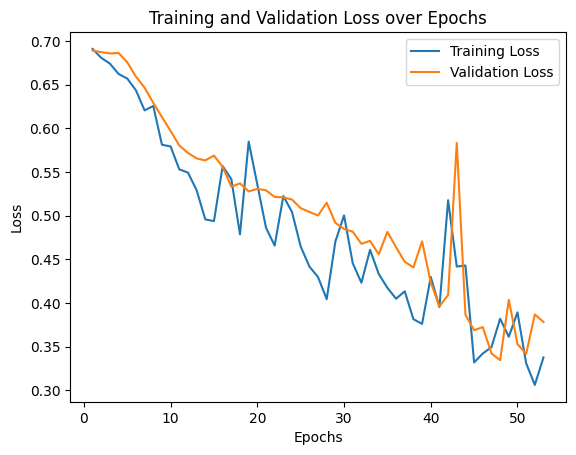

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

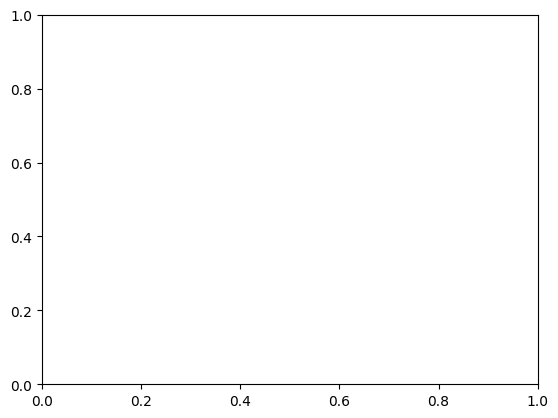

In [ ]:
train_losses = []
valid_losses = []
train_acc = []
valid_acc = []
train_total_steps = len(train_loader)
val_total_steps = len(val_loader)
last_epoch = 0

for epoch in range(TrainingConfig.NUM_EPOCHS):
    running_loss = 0.0
    running_acc = 0.0

    model.train()
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device).float()  # float para o BCE

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs.squeeze(dim=1), labels)
        acc = metric(outputs.squeeze(), labels) * 100

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += acc

    valid_loss = 0.0
    validation_acc = 0.0

    model.eval()
    with torch.no_grad():
        for i, (images, labels) in enumerate(val_loader):
            images = images.to(device)
            labels = labels.to(device).float()

            target = model(images)
            loss = criterion(target.squeeze(dim=1), labels)
            acc = metric(target.squeeze(), labels) * 100

            valid_loss += loss.item()
            validation_acc += acc

    avg_train_loss = running_loss / train_total_steps  # Média da perda para a época
    avg_valid_loss = valid_loss / val_total_steps
    avg_train_acc = running_acc / train_total_steps # Média da acurácia de treinamento
    avg_valid_acc = validation_acc / val_total_steps  # Média da acurácia de validação

    # Armazenando os valores das perdas
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)
    train_acc.append(avg_train_acc)
    valid_acc.append(avg_valid_acc)

    scheduler.step(avg_valid_loss)

    print(f'Epoch [{epoch+1}/{TrainingConfig.NUM_EPOCHS}] \t\t '
      f'TLoss: {avg_train_loss:.4f} \t\t '
      f'VLoss: {avg_valid_loss:.4f} \t\t '
      f'TAcc: {avg_train_acc:.2f}% \t\t '
      f'VAcc: {avg_valid_acc:.2f}%')


    if es(model, avg_valid_loss):
        last_epoch = epoch + 1
        print(f"Early stopping ativado na época {epoch+1}")
        break

else:
    last_epoch = TrainingConfig.NUM_EPOCHS

print('Treinamento completo')

plot_curves("Loss", train_losses, valid_losses,last_epoch)
plot_curves("Accuracy",train_acc, valid_acc,last_epoch)


Loop de teste

In [ ]:
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device) # qualquer coisa adicionar .float()
        labels = labels.to(device)
        print(labels)

        # Forward pass
        outputs = model(images)
        print(outputs)

        # Converte logits para probabilidades
        probabilities = outputs #torch.sigmoid(outputs)
        print(probabilities)

        # A CNN deu um valor bruto (logit) -> dps apliquei o sigmoid -> Pego esse valor e arredondo pra 1 ou 0
        predicted = torch.round(probabilities.view(-1))


        all_predictions.extend(predicted.cpu().tolist())
        all_targets.extend(labels.view(-1).cpu().tolist())

        print(all_predictions)
        print(all_targets)

    final_accuracy = accuracy_score(all_targets, all_predictions)
    print(f"Test Accuracy: {final_accuracy * 100:.2f}%")

tensor([1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0], device='cuda:0')
metatensor([[0.6768],
        [0.7631],
        [0.7975],
        [0.8878],
        [0.0095],
        [0.6342],
        [0.0148],
        [0.2430],
        [0.6263],
        [0.4767],
        [0.7501],
        [0.0054]], device='cuda:0')
metatensor([[0.6768],
        [0.7631],
        [0.7975],
        [0.8878],
        [0.0095],
        [0.6342],
        [0.0148],
        [0.2430],
        [0.6263],
        [0.4767],
        [0.7501],
        [0.0054]], device='cuda:0')
[1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0]
[1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0]
tensor([0, 0, 1, 1, 0, 1, 0, 0, 0, 0], device='cuda:0')
metatensor([[0.6647],
        [0.0940],
        [0.7885],
        [0.6551],
        [0.0155],
        [0.6015],
        [0.8811],
        [0.2355],
        [0.0040],
        [0.4148]], device='cuda:0')
metatensor([[0.6647],
        [0.0940],
        [0.7885],
        [0.6551],
        [0.0155],
        [0.6

Loop de teste utilizando um modelo com pesos salvos

tensor([1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0], device='cuda:0')
metatensor([[0.6503],
        [0.6995],
        [0.7090],
        [0.6766],
        [0.0154],
        [0.6674],
        [0.0108],
        [0.5595],
        [0.6319],
        [0.6956],
        [0.7006],
        [0.0037]], device='cuda:0')
metatensor([[0.6503],
        [0.6995],
        [0.7090],
        [0.6766],
        [0.0154],
        [0.6674],
        [0.0108],
        [0.5595],
        [0.6319],
        [0.6956],
        [0.7006],
        [0.0037]], device='cuda:0')
[1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0]
[1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0]
ERRO - Arquivo| Verdadeiro: 0 | Previsto: 1.0


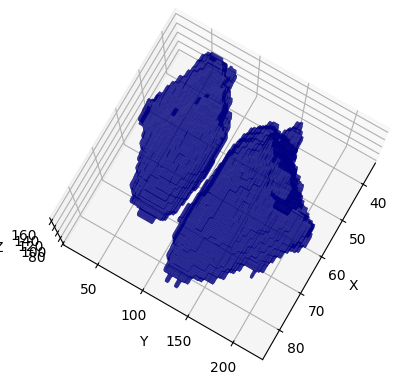

tensor([0, 0, 1, 1, 0, 1, 0, 0, 0, 0], device='cuda:0')
metatensor([[0.6333],
        [0.4506],
        [0.7585],
        [0.7143],
        [0.0016],
        [0.6668],
        [0.4995],
        [0.6265],
        [0.0134],
        [0.6477]], device='cuda:0')
metatensor([[0.6333],
        [0.4506],
        [0.7585],
        [0.7143],
        [0.0016],
        [0.6668],
        [0.4995],
        [0.6265],
        [0.0134],
        [0.6477]], device='cuda:0')
[1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0]
[1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0]
ERRO - Arquivo| Verdadeiro: 0 | Previsto: 1.0


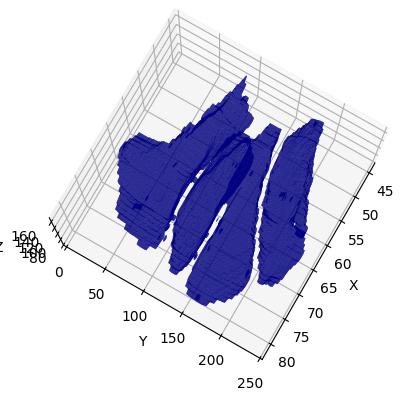

ERRO - Arquivo| Verdadeiro: 0 | Previsto: 1.0


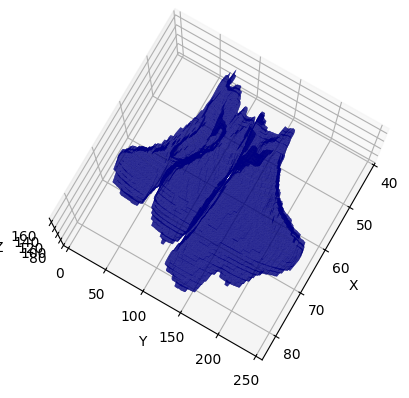

ERRO - Arquivo| Verdadeiro: 0 | Previsto: 1.0


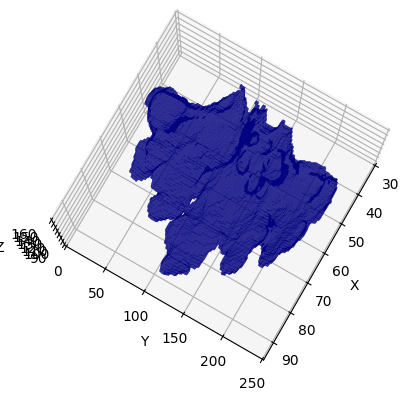

Test Accuracy: 81.82%


In [45]:
model.load_state_dict(torch.load("/home/labian-2/Desktop/Crateus/odonto_forense/model_weights/model_1_fold1.pt", map_location=device))
model = model.to(device)

model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device) # qualquer coisa adicionar .float()
        labels = labels.to(device)
        print(labels)

        # Forward pass
        outputs = model(images)
        print(outputs)

        # Converte logits para probabilidades
        probabilities = outputs #torch.sigmoid(outputs)
        print(probabilities)

        # A CNN deu um valor bruto (logit) -> dps apliquei o sigmoid -> Pego esse valor e arredondo pra 1 ou 0
        predicted = torch.round(probabilities.view(-1))
        labels_flat = labels.view(-1)


        all_predictions.extend(predicted.cpu().tolist())
        all_targets.extend(labels.view(-1).cpu().tolist())

        print(all_predictions)
        print(all_targets)

        for i in range(len(predicted)):
            pred = predicted[i].item()
            target = labels_flat[i].item()
            volume = images[i].cpu()

            if pred != target:
                print(f"ERRO - Arquivo| Verdadeiro: {target} | Previsto: {pred}")
                # Remove canal se tiver 1 canal apenas (formato [1, H, W, D] -> [H, W, D])
                if volume.dim() == 4 and volume.size(0) == 1:
                    volume = volume.squeeze(0)

                # Plota diretamente o volume
                plot_volume(volume, colored=True)

    final_accuracy = accuracy_score(all_targets, all_predictions)
    print(f"Test Accuracy: {final_accuracy * 100:.2f}%")

Matrix Confusão

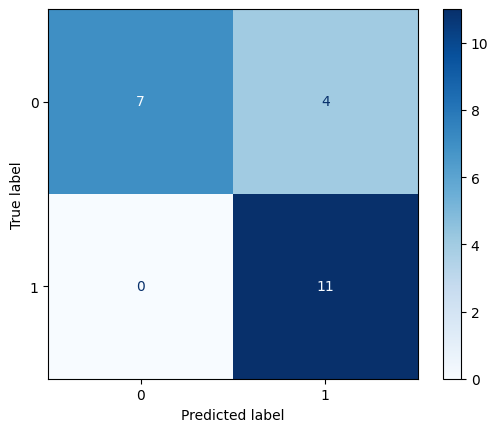

In [37]:
conf_matrix = confusion_matrix(all_targets, all_predictions)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.show()

In [38]:
from sklearn.metrics import classification_report


print(classification_report(all_targets, all_predictions, target_names=class_names, digits=4))

              precision    recall  f1-score   support

      Homens     1.0000    0.6364    0.7778        11
    Mulheres     0.7333    1.0000    0.8462        11

    accuracy                         0.8182        22
   macro avg     0.8667    0.8182    0.8120        22
weighted avg     0.8667    0.8182    0.8120        22

